<a href="https://colab.research.google.com/github/elena1346/Practica-01/blob/main/Pr%C3%A1ctica1_B%C3%BAsquedas_en_API_Tatoeba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Búsquedas automáticas en un corpus a través de una API pública: Tatoeba

## Objetivos
- Entender qué es una **API** y sus ventajas en PLN.
- Hacer **búsquedas** de ejemplos en un corpus desde su API.
- Pedir datos en formato **JSON** desde una API.
- Construir **tablas** (pandas), **concordancias (KWIC)** y **gráficos** simples.
- Exportar resultados a **CSV** y reflexionar sobre límites/sesgos del método.


## ¿Qué es una API?
Una API (*Application Programming Interface*) es una interfaz de acceso a los datos almacenados en un repositorio. Es la forma estándar de pedir datos o servicios a un sistema a través de peticiones (generalmente HTTP) y recibir respuestas en formatos estructurados (como JSON).

El proceso siempre tiene dos pasos: nosotros enviamos una **petición** (*request*) indicando qué queremos (la palabra a buscar, el idioma, el número de resultados…), y el servidor nos devuelve una **respuesta** (*response*) con los datos en formato JSON.

En lingüística computacional, las APIs permiten automatizar consultas a corpora y producir resultados reproducibles (mismo código → misma salida). Frente al buscador web de un corpus, la API permite recuperar grandes volúmenes de datos de forma automática y en un formato directamente manipulable, ya que están pensadas para que las pueda usar un programa.

Además, usar una API permite trabajar 100% en línea. Esto tiene la ventaja de que no es necesario descargar corpus enteros.

## Conceptos clave

- **JSON**: formato de datos estructurado en forma de pares clave-valor, muy parecido a un diccionario de Python. Es el formato en que la API nos devuelve los datos. En esta práctica convertiremos los datos de salida JSON a tablas pandas. El código navega por la estructura JSON para extraer, de cada resultado, el texto original (`text`) y el texto de la traducción (`translations → text`), y construye con ellos una tabla.

  Este es un ejemplo simplificado de lo que devuelve Tatoeba para la búsqueda de *banco*:

```json
{
  "results": [
    {
      "id": 123456,
      "text": "Fui al banco a sacar dinero.",
      "lang": "spa",
      "translations": [[{"id": 789012, "text": "I went to the bank.", "lang": "eng"}]]
    },
    {
      "id": 234567,
      "text": "Me senté en el banco del parque.",
      "lang": "spa",
      "translations": [[{"id": 890123, "text": "I sat on the bench.", "lang": "eng"}]]
    }
  ]
}
```

- **Librería** es un conjunto de funciones ya escritas que podemos reutilizar
en nuestro código. En lugar de programar desde cero cómo hacer una petición HTTP o cómo crear una tabla, importamos librerías que ya lo hacen. `import nombre_librería` es la instrucción para cargarlas.

- **Expresiones regulares (*regex*)**: es el lenguaje para describir patrones de texto. En lugar de buscar una cadena exacta, permiten buscar cualquier texto que cumpla una estructura determinada. En este cuaderno las usaremos para buscar patrones morfosintácticos y para construir las concordancias KWIC. Por ejemplo, el patrón `\bestar\b\s+\w+ndo\b` encuentra cualquier construcción *estar + gerundio* (*estar hablando*, *estar comiendo*…).

  | Patrón (regex) | Significa | Encuentra |
  |---|---|---|
  | `\bbanco\b` | "banco" como palabra completa | *banco* pero no *bancos* o *bancario*|
  | `\d+` | uno o más dígitos | *3*, *42*, *2024*… |
  | `(?i)\bbanco\b` | búsqueda sin distinguir mayúsculas | *banco*, *Banco*, *BANCO* |
  | `\bestar\b\s+\w+ndo\b` | "estar" + espacio + palabra acabada en *-ndo* | *estar hablando*, *estar comiendo*… |



  **¿Cómo leer un patrón regex?** Ejemplo: `\bestar\b\s+\w+ndo\b`

  | Fragmento | Significa |
  |---|---|
  | `\b` | límite de palabra (la palabra empieza o termina aquí) |
  | `estar` | literalmente la cadena "estar" |
  | `\s+` | uno o más espacios |
  | `\w+` | uno o más letras (cualquier secuencia) |
  | `ndo` | literalmente la cadena "ndo" |

  En conjunto: *"la palabra 'estar' completa, seguida de un espacio, seguida de
  cualquier palabra que acabe en -ndo"*. Encuentra *estar hablando*, *estar comiendo*…
  pero no *estará hablando* (porque *estará* ≠ *estar*).

## Otros conceptos
- **Corpus paralelo:** conjunto de textos en un idioma alineados con su traducción en otro idioma.
- **Tatoeba**: corpus de carácter colaborativo con traducciones en distintos idiomas.
- **Concordancia (KWIC; *Key Word In Context*):** ejemplos de un término/expresión con contexto a la izquierda y a la derecha del mismo.
- **Alineación:** correspondencia entre segmentos (oraciones/frases) de dos lenguas.
- **Parámetros de consulta (genéricos)**: *source* (idioma origen), *target* (idioma destino), *corpus* (subcorpus), *q* (*query*; consulta).
- **Parámetros de la API de Tatoeba**: `query` (texto a buscar), `from` (idioma origen), `to` (idioma destino), `page`, `sort`.
- **Endpoint**: URL de la API a la que hacemos la petición. En este caso práctico: `https://tatoeba.org/eng/api_v0/search`.



## 1) Preparación del entorno
Importamos librerías (no hace falta instalar nada adicional):
- `requests`: es la librería que permite hacer peticiones HTTP, es decir, la que se encarga de "llamar" a la API y traer la respuesta.
- `pandas` es la librería estándar para trabajar con tablas de datos en Python. La usaremos para convertir los datos JSON en tablas y manipularlos.
- `matplotlib.pyplot`: es la librería de visualización. La usaremos para generar gráficos de barras.

In [1]:
import requests, pandas as pd, time, re, math
import matplotlib.pyplot as plt
from typing import List, Dict, Any
pd.set_option('display.max_colwidth', 160)

## 2) Funciones para consultar la API de Tatoeba

En esta sección definimos las funciones que usaremos a lo largo de toda la práctica. Las funciones principales son:

- `fetch_tatoeba`: hace la petición a la API y devuelve los resultados como tabla.
- `clean_subset`: aplica filtros de limpieza al corpus recuperado.
- `kwic`: genera concordancias KWIC a partir de los resultados.
- `top_translations` y `token_top`: calculan las traducciones más frecuentes.

Se incluyen reintentos suaves (para no saturar el servicio), paginación y conversión a DataFrame.

In [2]:
BASE_URL = "https://tatoeba.org/eng/api_v0/search"

def safe_get(url, params, retries=3, pause=0.7):
    """Pide JSON con pequeños reintentos."""
    for i in range(retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 200:
            return r.json()
        time.sleep(pause * (i + 1))
    r.raise_for_status()

def normalize_lang(code: str) -> str:
    """Tatoeba usa ISO-639 de 3 letras: es=spa, en=eng, fr=fra, it=ita..."""
    mapping = {'es':'spa','en':'eng','fr':'fra','pt':'por','it':'ita','de':'deu','ca':'cat','gl':'glg'}
    return mapping.get(code.lower(), code.lower())

def fetch_tatoeba(query: str, source_lang: str = "spa", target_lang: str = "eng",
                  max_results: int = 400, sort: str = "relevance") -> pd.DataFrame:
    """Busca oraciones en Tatoeba y devuelve un DataFrame con columnas:
       id_src, src, id_trg, trg_lang, trg.
       Toma la primera traducción disponible en el idioma destino.
       Maneja tanto traducciones como lista de dicts como lista de listas.
    """
    src = normalize_lang(source_lang)
    trg = normalize_lang(target_lang)

    rows = []
    per_page = 100
    pages = math.ceil(max_results / per_page)
    got = 0
    page = 1

    while got < max_results and page <= pages:
        params = {"query": query, "from": src, "to": trg, "sort": sort, "page": page}
        js = safe_get(BASE_URL, params=params)
        results = js.get("results") or []
        if not results:
            break

        for s in results:
            es_text = s.get("text", "")
            es_id = s.get("id")
            translations = s.get("translations") or []

            tr_text = None
            tr_id = None
            tr_lang = None

            def consider(t):
                nonlocal tr_text, tr_id, tr_lang
                if isinstance(t, dict) and t.get("lang") == trg and tr_text is None:
                    tr_text = t.get("text")
                    tr_id = t.get("id")
                    tr_lang = t.get("lang")

            for item in translations:
                if isinstance(item, list):
                    for t in item:
                        consider(t)
                        if tr_text: break
                else:
                    consider(item)
                if tr_text: break

            rows.append({
                "id_src": es_id, "src": es_text,
                "id_trg": tr_id, "trg_lang": tr_lang, "trg": tr_text
            })
            got += 1
            if got >= max_results:
                break

        page += 1
        time.sleep(0.2)

    return pd.DataFrame(rows)

def kwic(series_or_df, term: str, column: str = "src", window: int = 45) -> pd.DataFrame:
    """Genera concordancias simples: L (left), M (match), R (right))."""
    if isinstance(series_or_df, pd.DataFrame):
        series = series_or_df[column] if column in series_or_df.columns else pd.Series([])
    else:
        series = pd.Series(series_or_df)
    term_re = re.compile(rf"(?i)\b{re.escape(term)}\b")
    rows = []
    for s in series.dropna().astype(str):
        for m in term_re.finditer(s):
            L = s[max(0, m.start()-window):m.start()].strip()
            M = s[m.start():m.end()]
            R = s[m.end():m.end()+window].strip()
            rows.append((L, M, R))
    return pd.DataFrame(rows, columns=["L", "M", "R"])

def clean_subset(df: pd.DataFrame, text_col="src",
                 min_len=3, max_len=140, allow_digits=False, drop_dupes=True):
    before = len(df)
    out = df.copy()
    out[text_col] = out[text_col].fillna("").astype(str).str.strip()
    out = out[out[text_col].str.len().between(min_len, max_len, inclusive="both")]
    if not allow_digits:
        out = out[~out[text_col].str.contains(r"\d")]
    if drop_dupes:
        out = out.drop_duplicates(subset=[text_col, "trg"], keep="first")
    after = len(out)
    stats = {"before": before, "after": after, "removed": before - after,
             "removed_pct": round(100*(before - after)/before, 2) if before else 0.0}
    return out.reset_index(drop=True), stats

def top_translations(df: pd.DataFrame, n=20):
    s = df["trg"].fillna("").str.strip()
    top = (s[s!=""].value_counts().head(n)
           .rename_axis("translation").reset_index(name="freq"))
    return top

def sample_by_translation(df: pd.DataFrame, translation: str, k=2):
    sub = df[df["trg"].fillna("").str.strip().str.lower() == translation.lower()]
    return sub[["src","trg"]].head(k)

def first_token(s):
    s = str(s).strip().lower() if s is not None else ""
    m = re.match(r"([a-z\-']+)", s)
    return m.group(1) if m else None

def token_top(df: pd.DataFrame, n=20, col="trg"):
    top = (df[col].map(first_token).value_counts().head(n)
           .rename_axis("translation_head").reset_index(name="freq"))
    return top

## 3) Búsqueda básica: una palabra polisémica
En esta sección  se ejecuta una búsqueda real contra la API. Vamos a buscar `banco` (español → inglés) y a crear un pequeño **KWIC** y un recuento de traducciones.

In [3]:
df = fetch_tatoeba("banco", source_lang="es", target_lang="en", max_results=300, sort="relevance")
print("Filas recuperadas:", len(df))
df.head(10)


Filas recuperadas: 30


,id_src,src,id_trg,trg_lang,trg
0,13362627,Fuimos al banco.,13835958,eng,We went to the bank.
1,3155722,Fui al banco.,3154910,eng,I went to the bank.
2,564464,Voy al banco.,256982,eng,I'm going to the bank.
3,14019538,Los bancos están cerrados.,3635827,eng,The banks are closed.
4,13030744,Saqué dinero del banco.,12955139,eng,I withdrew money from the bank.
5,10787132,Tom robó un banco.,4660538,eng,Tom robbed a bank.
6,10786430,Tom asaltó un banco.,4660538,eng,Tom robbed a bank.
7,6989491,Quiero ir al banco.,13046915,eng,I want to go to the bank.
8,5711752,¿Cuándo abre el banco?,4053875,eng,When does the bank open?
9,5026844,Trabajo en un banco.,663084,eng,I work in a bank.


In [4]:

# KWIC en el texto paralelo en español
kwic_es = kwic(df, "banco", column="src", window=45)
kwic_es.head(10)


,L,M,R
0,Fuimos al,banco,.
1,Fui al,banco,.
2,Voy al,banco,.
3,Saqué dinero del,banco,.
4,Tom robó un,banco,.
5,Tom asaltó un,banco,.
6,Quiero ir al,banco,.
7,¿Cuándo abre el,banco,?
8,Trabajo en un,banco,.
9,¿Está trabajando el,banco,?


In [10]:
# Usamos top_translations para obtener las traducciones más frecuentes (cadena exacta)
top = top_translations(df, n=20)
top

,translation,freq
0,Is the bank open?,3
1,I'm going to the bank.,2
2,I work in a bank.,2
3,Tom robbed a bank.,2
4,I worked for a bank.,2
5,The banks are closed.,1
6,I went to the bank.,1
7,We went to the bank.,1
8,When does the bank open?,1
9,I want to go to the bank.,1


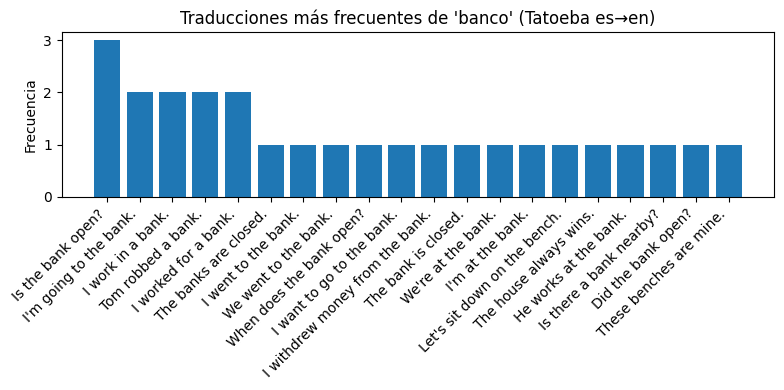

In [11]:
plt.figure(figsize=(8,4))
plt.bar(top["translation"], top["freq"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Traducciones más frecuentes de 'banco' (Tatoeba es→en)")
plt.tight_layout(); plt.show()

In [ ]:

# Usamos first_token para buscar el primer token de las traducciones más frecuentes en inglés.
top = (df["trg"].map(first_token)
         .value_counts().head(20)
         .rename_axis("traduccion").reset_index(name="freq"))
top

,traduccion,freq
0,i,7
1,is,5
2,the,3
3,i'm,3
4,he,2
5,tom,2
6,when,1
7,we,1
8,we're,1
9,let's,1


## 4) Búsquedas por patrones (p. ej., _estar + gerundio_)
Tatoeba solo permite buscar cadenas de texto exactas. Por tanto, la API no soporta expresiones regulares en el servidor, pero podemos recuperarlas y filtrar en local. Para ello, primero filtramos por palabras clave y después filtramos en local con regex.

In [12]:
df_estar_demo = fetch_tatoeba("estar", source_lang="es", target_lang="en", max_results=800, sort="relevance")
pat = re.compile(r"(?i)\bestar\b\s+\w+ndo\b")
df_estar_pat = df_estar_demo[df_estar_demo["src"].fillna("").str.contains(pat)]
print("Total estar:", len(df_estar_demo), "| patrón estar+gerundio:", len(df_estar_pat))
df_estar_pat.head(10)

Total estar: 80 | patrón estar+gerundio: 6


,id_src,src,id_trg,trg_lang,trg
32,12176821,Deberíamos estar ayudando.,2953771,eng,We should be helping.
43,10261170,Fingía estar durmiendo.,9965844,eng,He was pretending to be asleep.
60,8693889,Podría estar sobreactuando.,8693891,eng,He could be overreacting.
61,7966517,Deberías estar estudiando.,1420216,eng,You should be studying.
63,7110336,Deberías estar durmiendo.,2954736,eng,You should be sleeping.
72,5917129,Pareces estar mintiendo.,5916942,eng,You seem to be lying.


## 5) Cambiar idioma y dirección de la consulta
Puedes usar códigos de dos letras (`es`, `en`, `fr`, `it`…), el cuaderno los convertirá automáticamente a los códigos de Tatoeba. Esto permite comparar traducciones en distintas direcciones.

In [7]:

# Ejemplo: francés→español con el término 'banque' (banco financiero)
df_fr = fetch_tatoeba("banque", source_lang="fr", target_lang="es", max_results=200)
print("Filas fr→es:", len(df_fr))
df_fr.head(8)


Filas fr→es: 20


,id_src,src,id_trg,trg_lang,trg
0,11589882,Elle travaille à la banque.,534076,spa,Ella trabaja en un banco.
1,8237618,Il travaille à la banque.,726770,spa,Él trabaja en el banco.
2,6631151,Nous sommes à la banque.,3602874,spa,Estamos en el banco.
3,5149826,Je suis à la banque.,2817645,spa,Estoy en el banco.
4,4710958,Il pénétra dans la banque.,1639483,spa,Él entró al banco.
5,1117723,Je travaille pour une banque.,584345,spa,Yo trabajo para un banco.
6,663092,Je travaille dans une banque.,1121172,spa,Trabajo en el banco.
7,504871,Où est la banque ?,951274,spa,¿Dónde está el banco?


## 6) Descargar los resultados en CSV
Permite guardar los resultados de la búsqueda en local. En Colab, **los archivos descargados se alojan en una carpeta en el menú de la izquierda** y desaparecen al cerrar la sesión. El proceso de descarga comenzará una vez ejecutado el código.

In [13]:
df.to_csv("tatoeba_banco_es_en.csv", index=False)
df_estar_pat.to_csv("tatoeba_estar_gerundio_es_en.csv", index=False)
df_fr.to_csv("tatoeba_banque_fr_es.csv", index=False)

## 7) Buenas prácticas, límites y sesgos
- **Respeta la API**: usa pausas pequeñas y evita descargar miles de ejemplos en bucles rápidos.
- **Reproducibilidad**: documenta `query`, idiomas y fecha. Guarda el CSV.
- **Calidad/ruido**: Tatoeba es un corpus colaborativo que no está normalizado (contiene datos lingüísticos no sistematizados). Revisa los ejemplos y aplica filtros (longitud, caracteres, duplicados).
- **Cobertura**: no todos los idiomas tienen la misma cantidad/variedad de oraciones.


## 8) Ejercicios

1. **Ejercicio 1. Polisemia**: Elige un término polisémico (p. ej., `obra`,
`cola`, `cura`). Recupera ≥300 pares (por ejemplo, es→en) y clasifica las traducciones por sentido con 2 ejemplos por clase.
2. **Ejercicio 2. Patrones morfosintácticos**: Selecciona un patrón sinctáctico (por ejemplo, `seguir + gerundio`) y realiza la búsqueda en el corpus. Compara su traducción a otro idioma (por ejemplo, construcciones con be+V-ing en inglés).
3. **Ejercicio 3. Variación**: Cambia a `es→fr` y repite el análisis de `banco`. ¿Varían las traducciones dominantes? ¿Aparecen sentidos que no eran frecuentes en la primera búsqueda?
4. **Ejercicio 4. Direccionalidad**: Invierte `en→es` para `bank` y compara con `es→en`. ¿Observas alguna asimetría? ¿Encuentras algún ejemplo en el que difiera el mapeo?
5. **Ejercicio 5. Limpieza**: Implementa filtros (longitud mínima/máxima, sin dígitos, sin duplicados) y mide cómo cambian las frecuencias.
6. **Ejercicio 6. Limitaciones**: Tatoeba es un corpus de carácter colaborativo recopilado de manera no sistemática. ¿Has observado alguna inconsistencia en los datos? En vista de los resultados, ¿qué limitaciones tiene el uso de este corpus? ¿Para qué aplicaciones no sería recomendable?


## 9) Entregables

- Notebook con códigos ejecutables para cada ejercicio (archivo con extensión ipynb).
- Documento PDF con los ejercicios resueltos. Pueden incluirse gráficas, y capturas de pantalla.